In [10]:
# Builds a daily chart for the SF shelter waitlist

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from datetime import datetime
import seaborn as sns
import re

In [2]:
# seaborn styles
sns.set_style("whitegrid")

In [3]:
# compile regex for extracting date
extract_date = re.compile(r'(\d{4}-\d{2}-\d{2})')

In [4]:
df_list = []

for file in glob("waitlist_data/*.csv"):
    day = extract_date.search(file).group(0)
    df = pd.read_csv(file).assign( date = pd.to_datetime(day))
    df_list.append(df)

df = pd.concat(df_list)


<Axes: title={'center': 'Waitlist count by day'}>

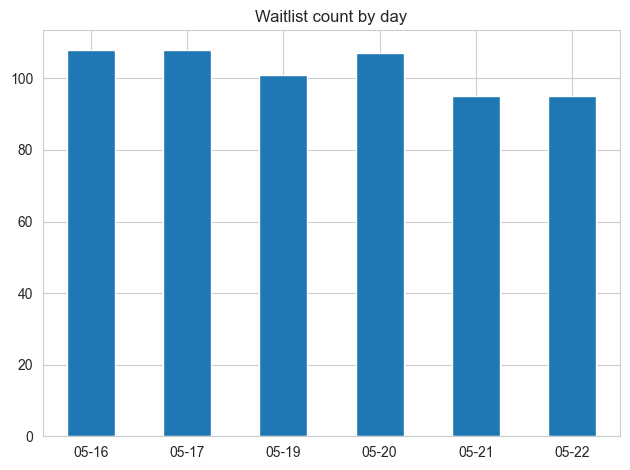

In [9]:
ax = (
    df
    .assign(
        day = lambda f: f["date"].dt.strftime("%m-%d"),
    )
    .groupby('day')
    ["Waitlist ID"]
    .count()
    .plot(
        kind = "bar",
        # rotate ticks
        rot = 0,
        title = "Waitlist count by day",
        xlabel=""
    )
)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("images/waitlist_count_by_day.png")
ax

---
---
---